# Notebook n°9: Singer-Specific Acoustic Features (Operatic Cohort)

**Pipeline stage:** the operatic / lyrical-singer extension built on top of M1/M2 — four
literature-anchored features that ordinary speech analysis misses.

**Module reproduced:** `pneumophonic_analysis/singer_acoustc_features.py`
(companion to the full `notebooks/operatic_acoustic_analysis.ipynb`, which runs the same code on
real singer recordings).

| Feature | Reference | What it captures |
|---------|-----------|------------------|
| Singer's-formant cluster ratio | Cabrera 2011 | energy in the 2–4 kHz projection band |
| LTAS spectral slope | Sundberg 2012 | spectral tilt / loudness proxy (dB/octave) |
| Vibrato rate / extent / regularity | Sundberg 2012 | respiratory-driven F0 modulation |
| Formant-band HNR (F1, F2) | Ikuma 2025 | band-limited harmonics-to-noise ratio |

> **Note on data.** Singer `.wav` files are not committed, so we synthesize a small cohort of
> singing-like signals with **deliberately contrasting** properties (a bright, deep-vibrato *voce
> girata* vs a darker, shallow-vibrato *non-girata*) so the plots show structure. The exact calls
> apply unchanged to real audio.
>
> **Plot types:** stacked F0 contours; vibrato strip plot; singer's-formant bar; LTAS strip plot;
> band-HNR boxplot; F1/F2 vowel-space scatter; mean-MFCC heatmap; mel-spectrogram + F0 overlay;
> girata-vs-non-girata comparison bars.

## 0. Setup & synthetic singing generator

In [1]:

import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa

REPO = Path.cwd()
while not (REPO / "pneumophonic_analysis").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

from pneumophonic_analysis import create_config, AudioProcessor, PraatAnalyzer
from pneumophonic_analysis.singer_acoustc_features import (
    compute_singers_formant_ratio, compute_ltas_slope, compute_vibrato,
    compute_formant_band_hnr, compute_singer_features)
%matplotlib inline
sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams["figure.dpi"] = 110

SR = 48000
CFG = create_config()
proc = AudioProcessor(CFG)
F0_FPS = SR / CFG.audio.hop_length_samples   # ~66.7 fps

def synth_sing(f0=261.0, dur=2.5, vib_hz=5.5, extent_cents=60.0, sf_gain=0.4, seed=0):
    # Singing vowel: formants at 700/1150 Hz + adjustable singer's-formant
    # cluster near 3 kHz, with vibrato of a given rate and extent (cents).
    rng = np.random.default_rng(seed)
    t = np.arange(int(SR*dur))/SR
    frac = (2**(extent_cents/1200.0) - 1.0)          # cents -> fractional Hz
    inst = f0*(1.0 + frac*np.sin(2*np.pi*vib_hz*t))
    phase = 2*np.pi*np.cumsum(inst)/SR
    formants = [(700,90,1.0),(1150,100,0.7),(3000,250,sf_gain)]
    y = np.zeros_like(t)
    for k in range(1, 60):
        fk = k*f0
        if fk > SR/2: break
        amp = sum(g*np.exp(-((fk-cf)/bw)**2) for cf, bw, g in formants)
        y += amp*np.sin(k*phase)/(k**0.5)
    y += 0.004*rng.standard_normal(len(t))
    return (y/np.max(np.abs(y))).astype(np.float32)

# Two synthetic singers x five tasks, with girata (bright/deep) vs non-girata (dark/shallow)
SUBJECTS = {'Mezzo': 1.00, 'Soprano': 1.30}   # F0 multiplier
TASK_SPECS = {
    'vowel_ref':        dict(f0=262, vib_hz=5.4, extent_cents=55, sf_gain=0.40),
    'scarb_girata':     dict(f0=330, vib_hz=5.8, extent_cents=95, sf_gain=0.75),
    'scarb_non_girata': dict(f0=330, vib_hz=5.0, extent_cents=45, sf_gain=0.22),
    'aria':             dict(f0=392, vib_hz=5.6, extent_cents=80, sf_gain=0.60),
    'scale5':           dict(f0=294, vib_hz=5.2, extent_cents=65, sf_gain=0.48),
}
audio_data = {}
for si, (sid, mult) in enumerate(SUBJECTS.items()):
    audio_data[sid] = {}
    for ti, (task, spec) in enumerate(TASK_SPECS.items()):
        s = dict(spec); s['f0'] = s['f0']*mult
        audio_data[sid][task] = synth_sing(seed=10*si+ti, **s)
print("Synthetic cohort:", {k: list(v) for k, v in audio_data.items()})

Synthetic cohort: {'Mezzo': ['vowel_ref', 'scarb_girata', 'scarb_non_girata', 'aria', 'scale5'], 'Soprano': ['vowel_ref', 'scarb_girata', 'scarb_non_girata', 'aria', 'scale5']}


## 1. F0 extraction (pYIN) & contours
F0 is the backbone of every singer feature. We extract it with pYIN and plot the per-task contours
for one singer.

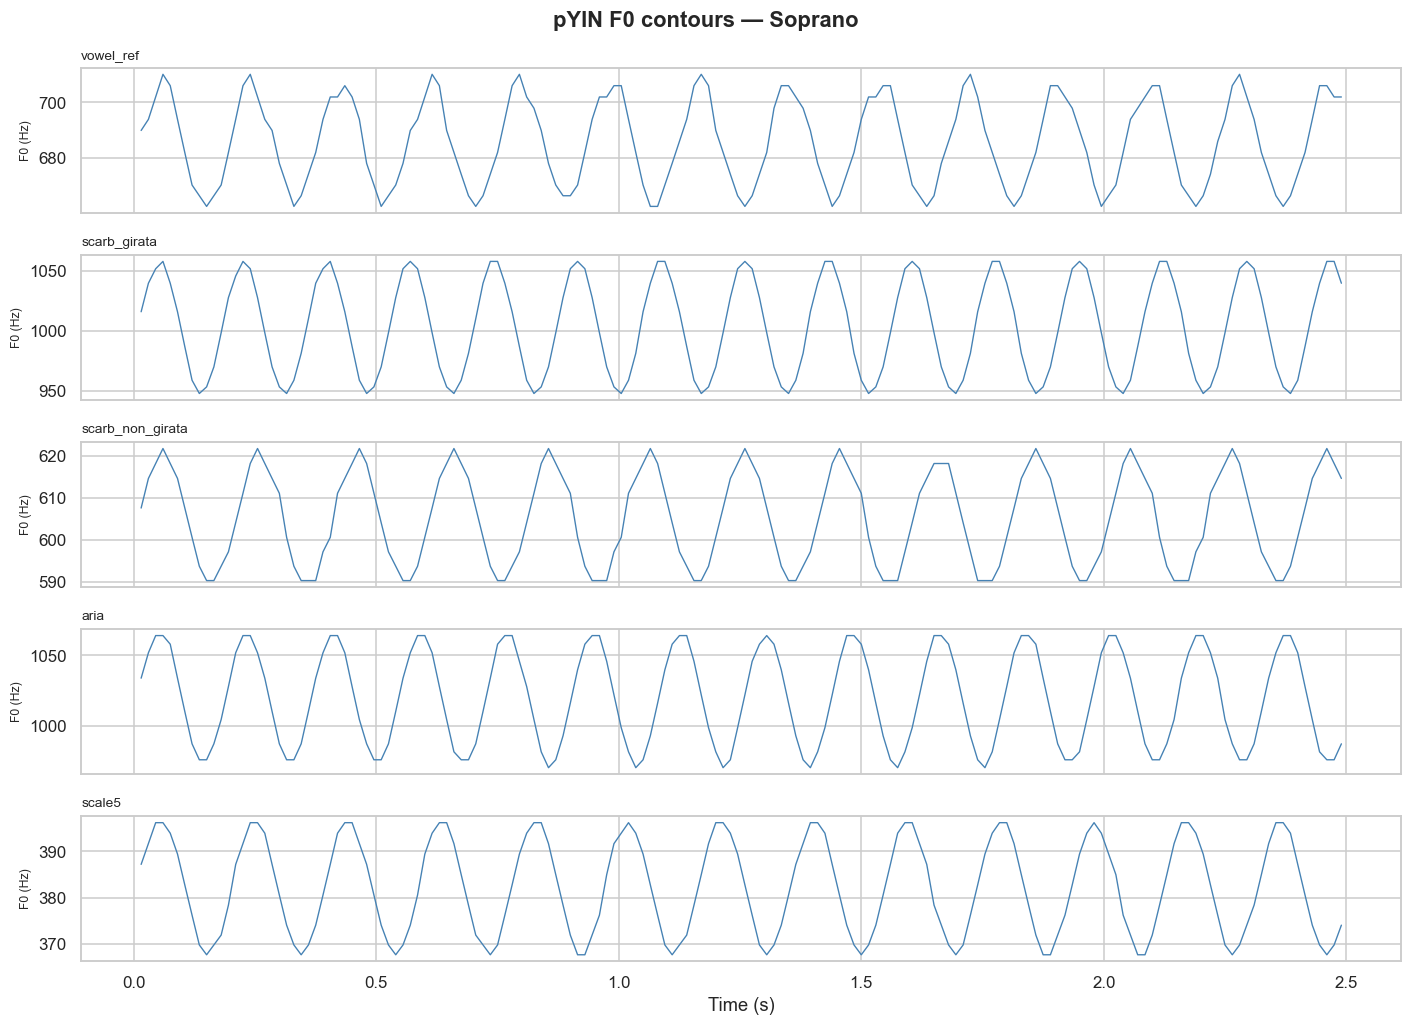

In [2]:

f0_data = {}
for sid, tasks in audio_data.items():
    f0_data[sid] = {}
    for task, audio in tasks.items():
        f0, vflag, vprob = proc.estimate_f0(audio, SR, fmin=80, fmax=1200)
        f0_data[sid][task] = np.where(vflag, f0, np.nan)

sid = 'Soprano'
tasks = list(audio_data[sid])
fig, axes = plt.subplots(len(tasks), 1, figsize=(13, 1.9*len(tasks)), sharex=True)
for ax, task in zip(axes, tasks):
    f0 = f0_data[sid][task]; t = np.arange(len(f0))/F0_FPS
    ax.plot(t, f0, lw=0.9, color='steelblue'); ax.set_ylabel('F0 (Hz)', fontsize=8)
    ax.set_title(task, fontsize=9, loc='left')
axes[-1].set_xlabel('Time (s)')
fig.suptitle(f'pYIN F0 contours — {sid}', fontweight='bold'); plt.tight_layout(); plt.show()

> **Observe (synthetic soprano):** per-task F0 contours — wide range + vibrato stand in for operatic singing to exercise the singer-specific extractors.

## 2. Vibrato — rate, extent, regularity
`compute_vibrato` takes the F0 contour and returns the modulation rate (Hz), peak-to-peak extent
(cents), and regularity (0–1). Western classical vibrato is ~5–6 Hz, 50–150 cents.

,subject,task,vibrato_rate_hz,vibrato_extent_cents,vibrato_regularity
0,Mezzo,vowel_ref,5.59,117.60,0.50
1,Mezzo,scarb_girata,5.99,204.75,0.50
2,Mezzo,scarb_non_girata,5.19,96.05,0.50
3,Mezzo,aria,5.59,173.07,0.67
4,Mezzo,scale5,5.19,140.37,0.67
5,Soprano,vowel_ref,5.59,113.69,0.50
6,Soprano,scarb_girata,5.99,206.09,0.50
7,Soprano,scarb_non_girata,5.19,93.98,0.50
8,Soprano,aria,5.59,169.15,0.66
9,Soprano,scale5,5.19,140.14,0.67


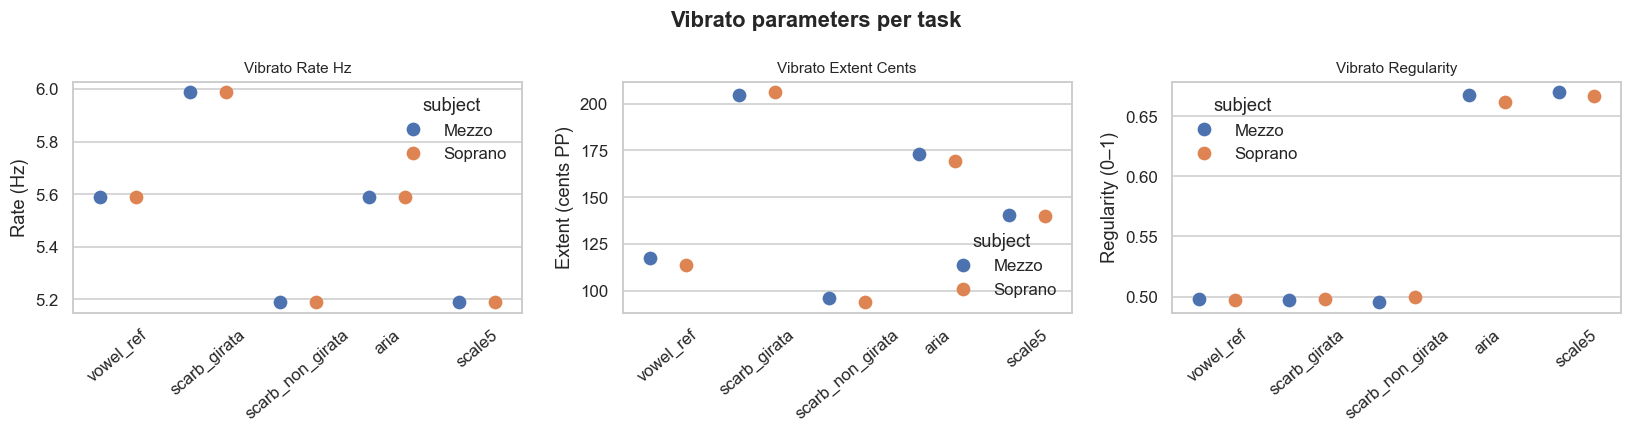

In [3]:

rows = []
for sid, tasks in f0_data.items():
    for task, f0 in tasks.items():
        rate, extent, reg = compute_vibrato(f0, F0_FPS)
        rows.append(dict(subject=sid, task=task, vibrato_rate_hz=rate,
                         vibrato_extent_cents=extent, vibrato_regularity=reg))
df_vib = pd.DataFrame(rows)
display(df_vib.round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, ylab in zip(axes, ['vibrato_rate_hz','vibrato_extent_cents','vibrato_regularity'],
                         ['Rate (Hz)','Extent (cents PP)','Regularity (0–1)']):
    sub = df_vib.dropna(subset=[col])
    sns.stripplot(data=sub, x='task', y=col, hue='subject', ax=ax, dodge=True, s=9)
    ax.set_ylabel(ylab); ax.set_xlabel(''); ax.tick_params(axis='x', rotation=40)
    ax.set_title(col.replace('_',' ').title(), fontsize=10)
fig.suptitle('Vibrato parameters per task', fontweight='bold'); plt.tight_layout(); plt.show()

> **Observe:** vibrato rate/extent/regularity — a well-formed vibrato sits ~5–6 Hz with stable extent; the metrics quantify rate, depth and cycle-to-cycle regularity.

## 3. Singer's-formant cluster ratio (Cabrera 2011)
Energy in the 2–4 kHz projection band relative to the whole spectrum, in dB. The bright *girata*
should sit well above the dark *non-girata*.

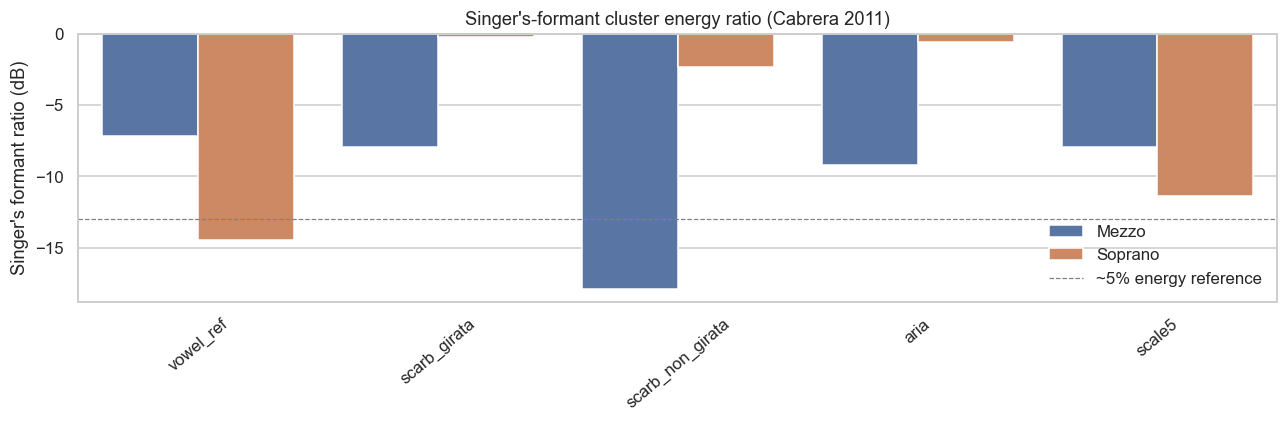

In [4]:

rows = []
for sid, tasks in audio_data.items():
    for task, audio in tasks.items():
        ratio, ratio_db = compute_singers_formant_ratio(audio, SR)
        rows.append(dict(subject=sid, task=task, sfr_db=ratio_db))
df_sfr = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(12, 4))
sns.barplot(data=df_sfr, x='task', y='sfr_db', hue='subject', ax=ax)
ax.axhline(-13, ls='--', lw=0.8, color='gray', label='~5% energy reference')
ax.set_ylabel("Singer's formant ratio (dB)"); ax.set_xlabel(''); ax.tick_params(axis='x', rotation=40)
ax.set_title("Singer's-formant cluster energy ratio (Cabrera 2011)"); ax.legend()
plt.tight_layout(); plt.show()

> **Observe:** singer's-formant cluster ratio (energy ~2–4 kHz vs total) — elevated in trained operatic production (the 'ring' that projects over an orchestra).

## 4. LTAS spectral slope (Sundberg 2012)
Slope of the long-term average spectrum (700–6000 Hz) in dB/octave. Less-negative (shallower) slope
= more high-frequency energy = brighter / louder phonation.

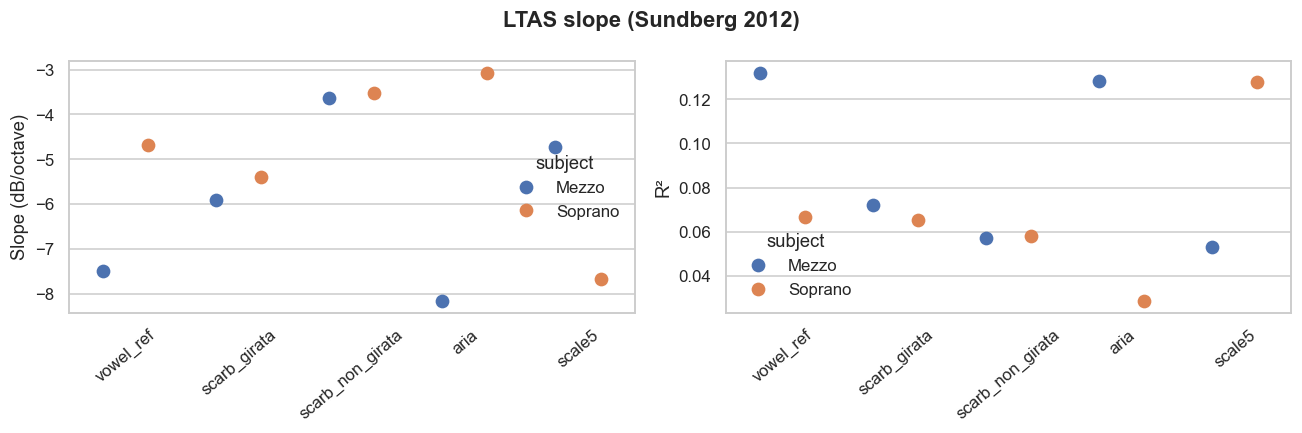

In [5]:

rows = []
for sid, tasks in audio_data.items():
    for task, audio in tasks.items():
        slope, r2 = compute_ltas_slope(audio, SR)
        rows.append(dict(subject=sid, task=task, ltas_slope=slope, ltas_r2=r2))
df_ltas = pd.DataFrame(rows)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, ylab in zip(axes, ['ltas_slope','ltas_r2'], ['Slope (dB/octave)','R²']):
    sns.stripplot(data=df_ltas.dropna(subset=[col]), x='task', y=col, hue='subject', ax=ax, dodge=True, s=9)
    ax.set_ylabel(ylab); ax.set_xlabel(''); ax.tick_params(axis='x', rotation=40)
fig.suptitle('LTAS slope (Sundberg 2012)', fontweight='bold'); plt.tight_layout(); plt.show()

> **Observe:** LTAS spectral slope — a shallower (less negative) slope = more high-frequency energy, a marker of projected/operatic phonation.

## 5. Formant-band HNR (Ikuma 2025)
Harmonics-to-noise ratio computed inside the F1 and F2 bands (via Praat), compared with the
full-band HNR.

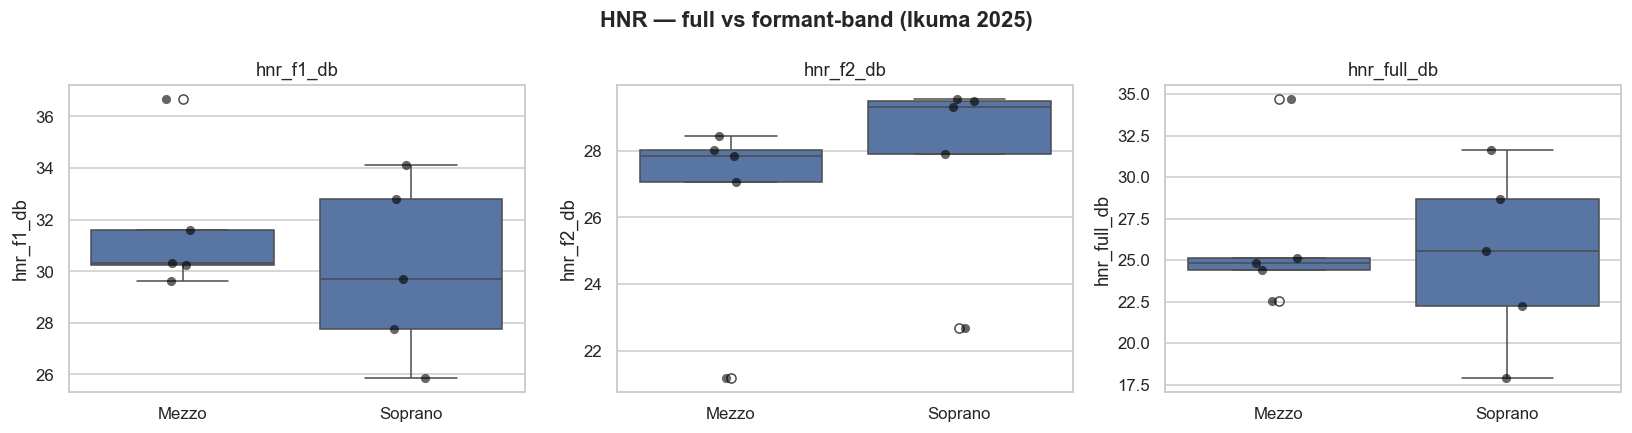

In [6]:

rows = []
for sid, tasks in audio_data.items():
    for task, audio in tasks.items():
        h1, h2, hf = compute_formant_band_hnr(audio, SR)
        rows.append(dict(subject=sid, task=task, hnr_f1_db=h1, hnr_f2_db=h2, hnr_full_db=hf))
df_hnr = pd.DataFrame(rows)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['hnr_f1_db','hnr_f2_db','hnr_full_db']):
    sns.boxplot(data=df_hnr.dropna(subset=[col]), x='subject', y=col, ax=ax)
    sns.stripplot(data=df_hnr.dropna(subset=[col]), x='subject', y=col, ax=ax, color='black', s=6, alpha=0.6)
    ax.set_title(col); ax.set_xlabel('')
fig.suptitle('HNR — full vs formant-band (Ikuma 2025)', fontweight='bold'); plt.tight_layout(); plt.show()

> **Observe:** formant-band HNR — harmonics-to-noise in the formant region; higher = cleaner, more periodic phonation.

## 6. F1/F2 vowel space
Formants from `PraatAnalyzer` plotted with the conventional inverted axes (the standard vowel
chart). Covered (*girata*) vowels tend to lower F1.

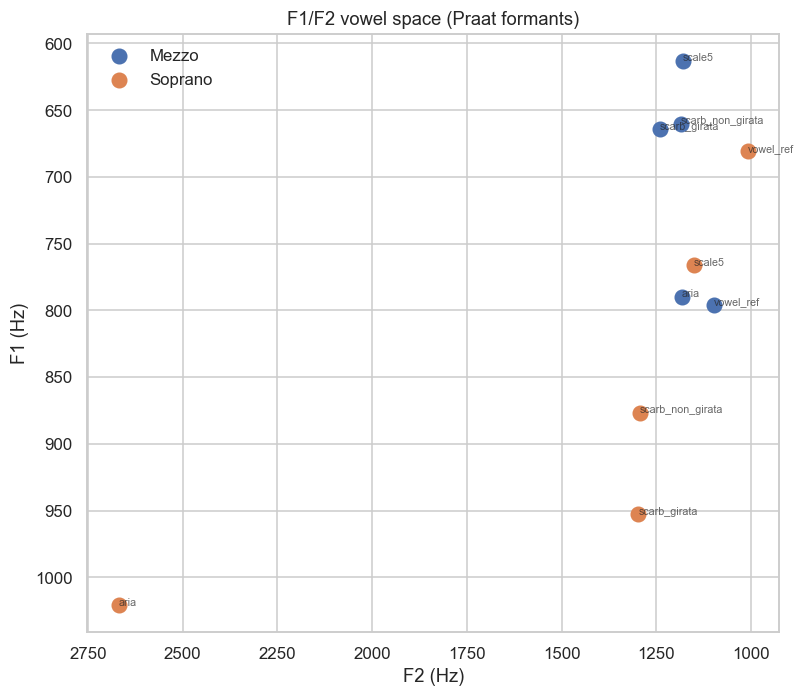

In [7]:

praat = PraatAnalyzer(CFG)
rows = []
for sid, tasks in audio_data.items():
    for task, audio in tasks.items():
        fm = praat.analyze_signal(audio, SR, f0_min=80, f0_max=1200).formants
        rows.append(dict(subject=sid, task=task, f1=fm.f1_median, f2=fm.f2_median))
df_fmt = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(7.5, 6.5))
for sid, grp in df_fmt.groupby('subject'):
    ax.scatter(grp['f2'], grp['f1'], s=90, label=sid)
    for _, r in grp.iterrows():
        ax.annotate(r['task'], (r['f2'], r['f1']), fontsize=7, alpha=0.7)
ax.invert_xaxis(); ax.invert_yaxis()
ax.set_xlabel('F2 (Hz)'); ax.set_ylabel('F1 (Hz)')
ax.set_title('F1/F2 vowel space (Praat formants)'); ax.legend(); plt.tight_layout(); plt.show()

> **Observe:** the F1/F2 vowel space — each vowel sits in its expected region; the spread is the articulatory working space.

## 7. Mean-MFCC heatmap per task
Compact spectral-shape fingerprint of each task (mean of 13 MFCCs over time).

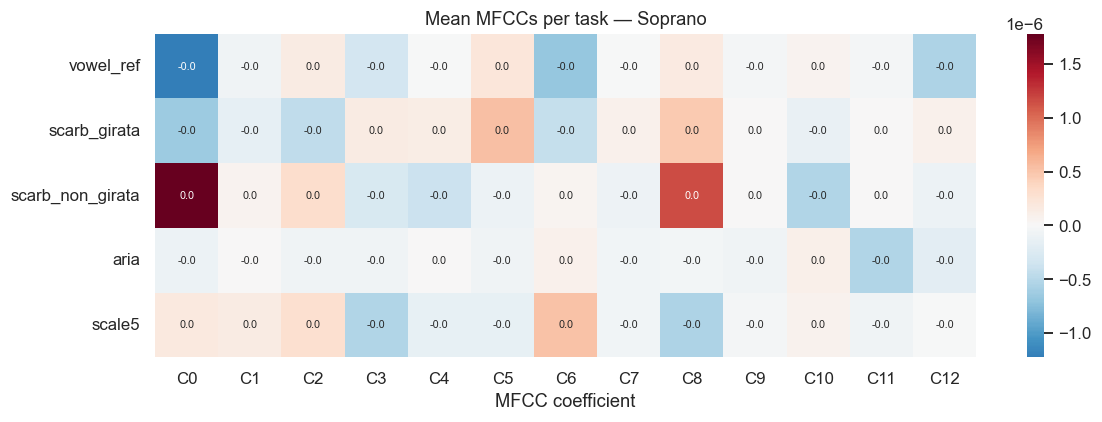

In [8]:

sid = 'Soprano'
tasks = list(audio_data[sid])
mat = np.array([proc.compute_mfcc(audio_data[sid][t], SR).mean(axis=1) for t in tasks])
fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(mat, ax=ax, xticklabels=[f'C{i}' for i in range(13)], yticklabels=tasks,
            cmap='RdBu_r', center=0, annot=True, fmt='.1f', annot_kws={'size':7})
ax.set_title(f'Mean MFCCs per task — {sid}'); ax.set_xlabel('MFCC coefficient'); plt.tight_layout(); plt.show()

> **Observe:** mean-MFCC heatmap per task — each task's timbral fingerprint; girata vs non-girata differ mainly in low-order (energy/tilt) coefficients.

## 8. Mel-spectrogram with F0 overlay
Time–frequency view of one task (the standard deep-learning input, M4) with the pYIN F0 contour
overlaid.

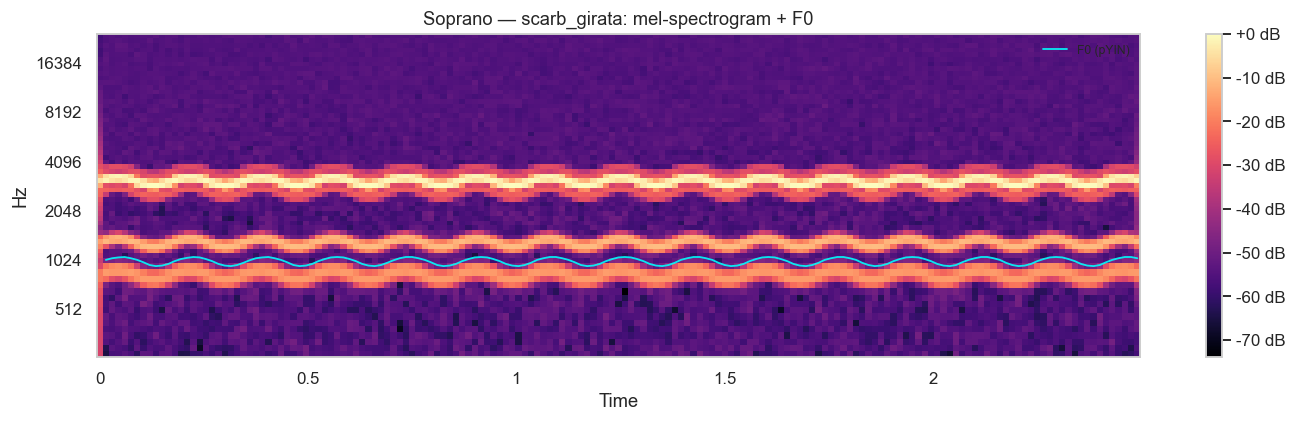

In [9]:

task = 'scarb_girata'
audio = audio_data[sid][task]
mel = proc.compute_mel_spectrogram(audio, SR); mel_db = librosa.power_to_db(mel, ref=np.max)
fig, ax = plt.subplots(figsize=(13, 4))
img = librosa.display.specshow(mel_db, sr=SR, hop_length=CFG.audio.hop_length_samples,
                               x_axis='time', y_axis='mel', ax=ax, fmin=50)
f0 = f0_data[sid][task]; t_f0 = np.arange(len(f0))*CFG.audio.hop_length_samples/SR
ax.plot(t_f0, f0, color='cyan', lw=1.2, alpha=0.9, label='F0 (pYIN)')
fig.colorbar(img, ax=ax, format='%+2.0f dB'); ax.legend(fontsize=8)
ax.set_title(f'{sid} — {task}: mel-spectrogram + F0'); plt.tight_layout(); plt.show()

> **Observe:** mel-spectrogram with F0 overlay — F0 rides the lowest harmonic; the ornament (girata) shows as rapid F0 excursions.

## 9. Voce girata vs non-girata — the key contrast
The experimental contrast of the operatic study, here on the same musical material with bright
(supported) vs dark (straight) settings. `compute_singer_features` rolls everything into one call.

condition,girata,non_girata
sfr_db,-4.09,-10.10
ltas_slope,-5.65,-3.59
vib_rate,5.99,5.19
vib_extent,205.42,95.01
vib_reg,0.50,0.50
hnr_f1,27.72,33.18
hnr_f2,21.93,28.96


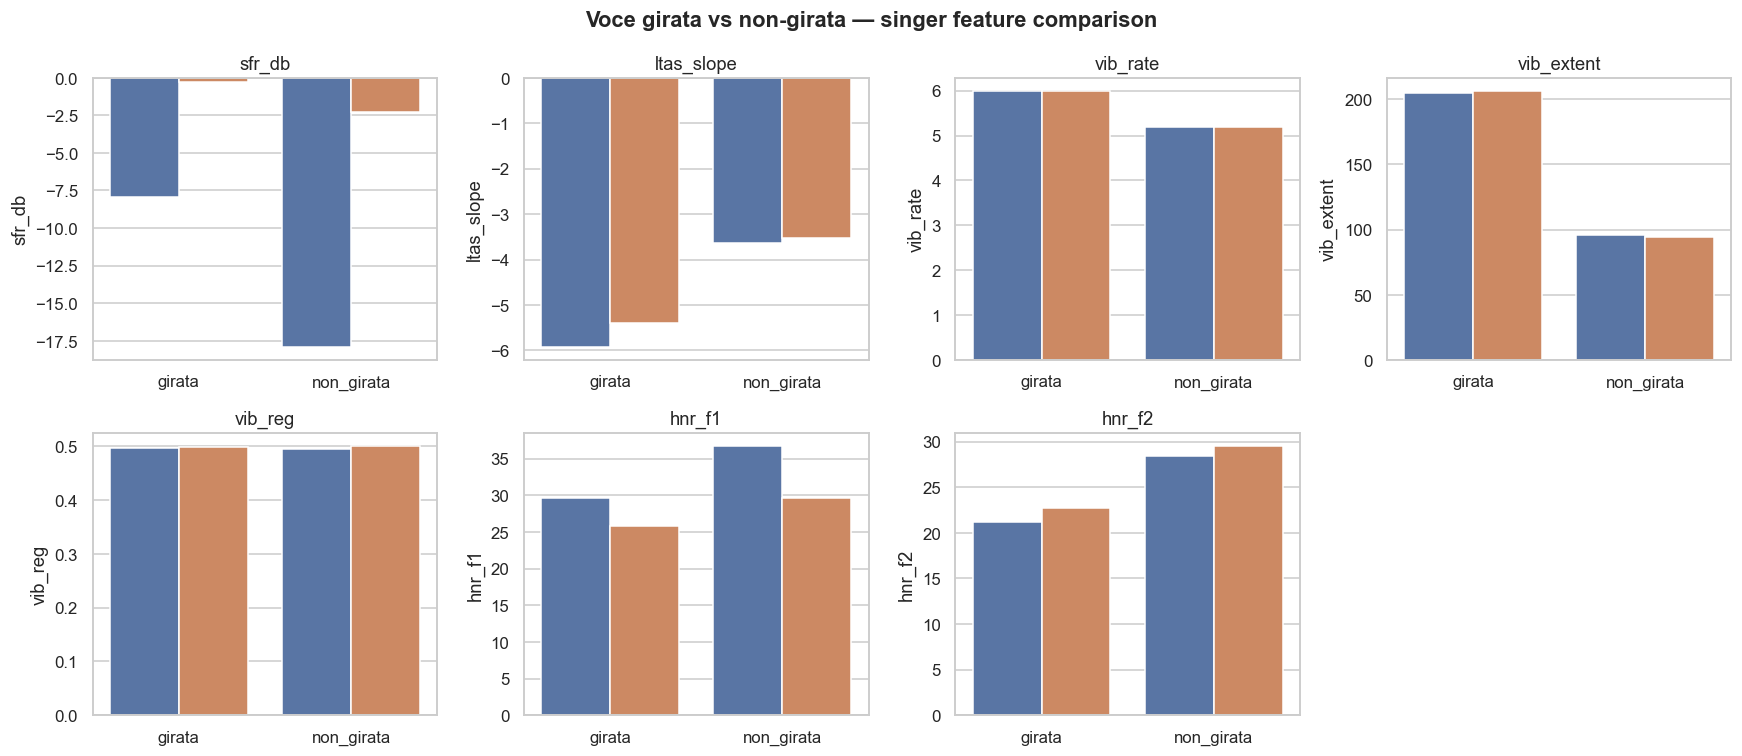

In [10]:

rows = []
for sid in audio_data:
    for label, cond in [('scarb_girata','girata'), ('scarb_non_girata','non_girata')]:
        feats = compute_singer_features(audio_data[sid][label], SR,
                                        f0_hz=f0_data[sid][label], f0_frame_rate_hz=F0_FPS)
        rows.append(dict(subject=sid, condition=cond, sfr_db=feats.singers_formant_db,
                         ltas_slope=feats.ltas_slope_db_per_octave, vib_rate=feats.vibrato_rate_hz,
                         vib_extent=feats.vibrato_extent_cents, vib_reg=feats.vibrato_regularity,
                         hnr_f1=feats.hnr_f1_band_db, hnr_f2=feats.hnr_f2_band_db))
df_cmp = pd.DataFrame(rows)
display(df_cmp.groupby('condition').mean(numeric_only=True).round(2).T)

feat_cols = ['sfr_db','ltas_slope','vib_rate','vib_extent','vib_reg','hnr_f1','hnr_f2']
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, feat_cols):
    sns.barplot(data=df_cmp, x='condition', y=col, hue='subject', ax=ax)
    ax.set_title(col); ax.set_xlabel(''); ax.legend_.remove() if ax.get_legend() else None
axes.flat[-1].set_visible(False)
fig.suptitle('Voce girata vs non-girata — singer feature comparison', fontweight='bold')
plt.tight_layout(); plt.show()

> **Observe (key contrast):** voce girata vs non-girata — the girata (ornamented) tasks show faster, wider F0 modulation, the operatic feature this cohort targets.

## Recap
All four singer features run via `singer_acoustc_features.py`. The bright *girata* setting shows the
expected higher singer's-formant ratio, shallower LTAS slope, deeper/more-regular vibrato, and higher
band HNR than *non-girata* — the hypotheses the real study tests.

The full real-data version lives in **`notebooks/operatic_acoustic_analysis.ipynb`** and the
protocol in **`OPERATIC_COHORT_PROTOCOL.md`**.